# **Human-in-the-Loop (HITL) in Agentic AI**

**Human-in-the-loop** refers to design patterns where an AI agent's autonomous workflow includes deliberate checkpoints where a human reviews, approves, corrects, or intervenes before the agent proceeds — rather than letting the agent act completely independently from start to finish.

### **Why it matters for agentic AI**

Agentic AI systems can plan multi-step tasks, call tools, use APIs, browse the web, write/execute code, or take real-world actions (send emails, make purchases, modify files, etc.). Because these actions can have real consequences and agents can make mistakes, drift off-task, or misinterpret ambiguous instructions, HITL introduces control points so mistakes don't cascade unchecked.

### **Common patterns**

| Pattern | Description |
|---|---|
| **Approval gates** | Agent proposes an action (e.g., "delete this file," "send this email") and waits for explicit human confirmation before executing |
| **Plan review** | Agent shows its planned sequence of steps before execution; human can edit or reject the plan |
| **Checkpointing** | Agent pauses at defined milestones in a long task for a human to verify progress |
| **Escalation/fallback** | Agent hands off to a human when it hits low confidence, an edge case, or a policy-sensitive decision |
| **Post-hoc review** | Agent acts autonomously but logs actions for human audit afterward (lower friction, less real-time safety) |
| **Interactive correction** | Human can interrupt mid-task to redirect or correct the agent |

### **Where you've likely seen it already**

- Claude Code / coding agents asking before running certain commands or making destructive edits
- Customer service bots escalating to a human agent for complex complaints
- AI systems requiring sign-off before sending an email or making a financial transaction
- Content moderation pipelines where AI flags content but a human makes the final call

### **Trade-offs**

- **Pros:** safety, accountability, error-catching, regulatory compliance, builds trust
- **Cons:** slows down automation, reintroduces bottlenecks, can defeat the purpose of "autonomous" agents if overused

### **The design question**

Most real systems aren't fully autonomous or fully human-gated — they sit on a spectrum. The key design decision is *where* to place the human checkpoints: usually before high-stakes, irreversible, or ambiguous actions, while letting low-risk, reversible actions run autonomously.

In [9]:
import os
import operator
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage, AnyMessage, SystemMessage
from langgraph.graph.message import add_messages
from pprint import pprint
from typing_extensions import TypedDict, Literal
from IPython.display import Image, display
from typing import Annotated, List
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field

In [5]:
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Call Model
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [7]:
# Custom tools

def multiply(a:float, b:float) -> float:
    """Multiply a by b
    Args:
        a: first float number
        b: second float number"""
    
    return a*b

def divide(a:float, b:float) -> float:
    """Divide a by b
    Args:
        a: first float number
        b: second float number"""
    
    return a/b

def add(a:float, b:float) -> float:
    """Add a by b
    Args:
        a: first float number
        b: second float number"""
    
    return a+b

def substract(a:float, b:float) -> float:
    """Substract a by b
    Args:
        a: first float number
        b: second float number"""
    
    return a-b


tools = [add, substract, multiply, divide]
tools

[<function __main__.add(a: float, b: float) -> float>,
 <function __main__.substract(a: float, b: float) -> float>,
 <function __main__.multiply(a: float, b: float) -> float>,
 <function __main__.divide(a: float, b: float) -> float>]

In [8]:
# Integrate tools with LLL
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001FB855A28D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001FB85705B90>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'Add a by b\nArgs:\n

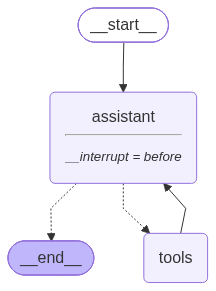

In [13]:
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Nodes
def assistant(state:MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state['messages'])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
    )
builder.add_edge("tools", "assistant")

memory = MemorySaver()

# Human in the loop
graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory)

# Display graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
thread = {"configurable": {"thread_id": "123"}}
initial_input = {"messages": HumanMessage(content="Multiply 4 by 8")}

In [15]:
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 4 by 8


In [18]:
# Check the next check point
state = graph.get_state(thread)
state.next

('assistant',)

In [26]:
(graph.get_state_history(thread))

<generator object Pregel.get_state_history at 0x000001FB857A7320>

In [27]:
# Continue the execution
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 4 by 8
================================== Ai Message ==================================
Tool Calls:
  multiply (ppq44ct04)
 Call ID: ppq44ct04
  Args:
    a: 4
    b: 8
================================= Tool Message =================================
Name: multiply

32.0


In [28]:
# Check the next check point
state = graph.get_state(thread)
state.next

('assistant',)

In [29]:
# Continue the execution
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

32.0
================================== Ai Message ==================================

The result of multiplying 4 by 8 is 32.0.


In [30]:
# Check the next check point
state = graph.get_state(thread)
state.next

()